In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
np.random.seed(42)

# Parameters
r = 0.05
sigma = 0.5
T = 1.0
S0 = 100.0
K = 110.0
B = 90.0

### 1. GBM simulation and Brownian bridge barrier crossing

In [14]:
# simulate stock price paths that follow GBM
def simulate_gbm_paths(S0, r, sigma, T, N_steps, N_paths, seed=None):
    """Exact GBM: S_t = S0 * exp((r - sigma^2/2)*t + sigma*W_t). Returns S (N_paths, N_steps+1) and W (N_paths, N_steps+1)."""
    if seed is not None:
        np.random.seed(seed)
    h = T / N_steps
    # Increments dW
    dW = np.random.standard_normal((N_paths, N_steps)) * np.sqrt(h)
    W = np.zeros((N_paths, N_steps + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)

    # S at each step: S_i = S0 * exp((r - sigma^2/2)*t_i + sigma*W_{t_i})
    t = np.linspace(0, T, N_steps + 1)
    S = S0 * np.exp((r - 0.5 * sigma ** 2) * t + sigma * W)
    return S, W, h

In [15]:
# Brownian bridge survival calculation
def brownian_bridge(S, h, sigma, B):
    log_S = np.log(S)
    log_B = np.log(B)
    sigma_sq = sigma ** 2
    log_S_i = log_S[:, :-1]
    log_S_ip1 = log_S[:, 1:]
    p_crossed = np.exp(-2.0 * (log_S_i - log_B) * (log_S_ip1 - log_B) / (sigma_sq * h))
    p_crossed[np.minimum(log_S_i, log_S_ip1) <= log_B] = 1.0
    one_minus_p = 1.0 - p_crossed
    return(one_minus_p)

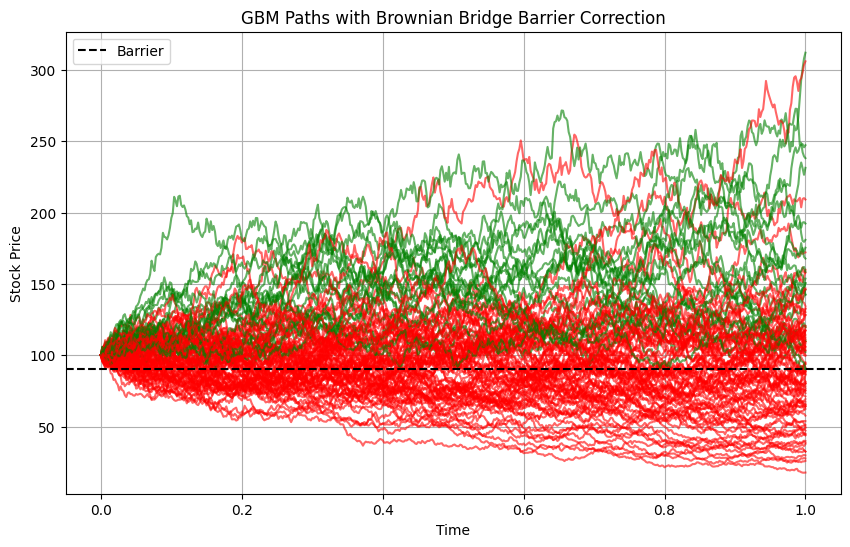

In [16]:
# Sample GBM paths using the barrier-crossing formula
N_paths_plot = 100
N_steps = 500

S, W, h = simulate_gbm_paths(S0, r, sigma, T, N_steps, N_paths_plot, seed=42)
t = np.linspace(0, T, N_steps + 1)

# Brownian bridge survival calculation
one_minus_p = brownian_bridge(S, h, sigma, B)
survival = np.prod(one_minus_p, axis=1)

# classify as "survived" if Brownian-bridge survival weight is positive
survived = survival > 0

plt.figure(figsize=(10, 6))

for i in range(N_paths_plot):
    if survived[i]:
        plt.plot(t, S[i], color='green', alpha=0.6, linewidth=1.5)
    else:
        plt.plot(t, S[i], color='red', alpha=0.6, linewidth=1.5)

plt.axhline(B, color = 'black', linestyle='--', linewidth=1.5, label='Barrier')
plt.title("GBM Paths with Brownian Bridge Barrier Correction")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.savefig("GBM.png")
plt.show()

### 2. Pathwise Delta and Vega

In [17]:
def pathwise_option_value(S, r, sigma, T, K, one_minus_p):
    """
    Calculates the value of down-and-out call with barrier crossing (survival product).
    S: (N_paths, N_steps+1)
    """
    N_paths, N_steps_plus_1 = S.shape
    N_steps = N_steps_plus_1 - 1
    
    # Brownian bridge survival calculation
    survival = np.prod(one_minus_p, axis=1)  # (N_paths,)

    ST = S[:, -1]

    payoff_disc = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    payoff_weighted = payoff_disc * survival
    return payoff_weighted


In [18]:
def pathwise_delta_vega(S, W, h, S0, r, sigma, T, K, B, one_minus_p):
    """
    Pathwise Delta and Vega for down-and-out call with barrier crossing (survival product).
    S, W: (N_paths, N_steps+1). Returns (delta_samples, vega_samples).
    """
    N_paths, N_steps_plus_1 = S.shape
    N_steps = N_steps_plus_1 - 1
    log_S = np.log(S)
    log_B = np.log(B)
    sigma_sq = sigma ** 2
    log_S_i = log_S[:, :-1]
    log_S_ip1 = log_S[:, 1:]
    
    # Brownian bridge survival calculation
    survival = np.prod(one_minus_p, axis=1)

    ST = S[:, -1]
    WT = W[:, -1]

    # Pathwise Delta:
    delta_pathwise = np.exp(-r * T) * (ST / S0) * (ST > K).astype(float) * survival
    term_dS0 = np.zeros(N_paths)
    for i in range(N_steps):
        surv_no_i = np.prod(one_minus_p[:, np.arange(N_steps) != i], axis=1)
        a_i = log_S_i[:, i] - log_B
        b_i = log_S_ip1[:, i] - log_B
        p_i = 1 - one_minus_p[:, i]
        term_dS0 += surv_no_i * p_i * 2.0 * (a_i + b_i) / (sigma_sq * h)
    d_survival_dS0 = term_dS0 / S0
    # Only add correction where survival > 0 (otherwise pathwise derivative of 0 is 0)
    mask = survival > 0
    delta_pathwise += np.exp(-r * T) * np.maximum(ST - K, 0.0) * d_survival_dS0 * mask

    # Pathwise Vega
    vega_pathwise = np.exp(-r * T) * ST * (WT - sigma * T) * (ST > K).astype(float) * survival
    term_dsigma = np.zeros(N_paths)
    for i in range(N_steps):
        surv_no_i = np.prod(one_minus_p[:, np.arange(N_steps) != i], axis=1)
        a_i = log_S_i[:, i] - log_B
        b_i = log_S_ip1[:, i] - log_B
        p_i = 1 - one_minus_p[:, i]
        term_dsigma += surv_no_i * p_i * 4.0 * a_i * b_i / (sigma ** 3 * h)
    d_survival_dsigma = term_dsigma
    vega_pathwise += np.exp(-r * T) * np.maximum(ST - K, 0.0) * d_survival_dsigma * mask
    
    return delta_pathwise, vega_pathwise

In [19]:
# Simulation parameters
N_paths = 750000
N_steps = 400

S, W, h = simulate_gbm_paths(S0, r, sigma, T, N_steps, N_paths, seed=42)
one_minus_p = brownian_bridge(S, h, sigma, B)
payoff_samples = pathwise_option_value(S, r, sigma, T, K, one_minus_p)
delta_samples, vega_samples = pathwise_delta_vega(S, W, h, S0, r, sigma, T, K, B, one_minus_p)

V_hat = np.mean(payoff_samples)
delta_hat = np.mean(delta_samples)
vega_hat = np.mean(vega_samples)

print(f"Option value (with barrier crossing): V_hat = {V_hat:.6f}")
print(f"Pathwise Delta = {delta_hat:.6f}")
print(f"Pathwise Vega  = {vega_hat:.6f}")
print(f"Std(V_hat) = {np.std(payoff_samples)/np.sqrt(N_paths):.6f}")
print(f"Std(Delta_hat) = {np.std(delta_samples)/np.sqrt(N_paths):.6f}")
print(f"Std(Vega_hat) = {np.std(vega_samples)/np.sqrt(N_paths):.6f}")

Option value (with barrier crossing): V_hat = 8.570200
Pathwise Delta = 0.855304
Pathwise Vega  = 23.157584
Std(V_hat) = 0.035042
Std(Delta_hat) = 0.006539
Std(Vega_hat) = 0.108950


### 3. Weak convergence in step size $h$
We check that the bias is **O(h)** by varying $N_{\text{steps}}$ (hence $h = T/N_{\text{steps}}$) and comparing to a fine reference.

In [ ]:
# Simulate the prices on refined grid

N_fine = 1600 # must be max of steps_list
N_paths_conv = 750000
S_fine, W_fine, h_fine = simulate_gbm_paths(S0, r, sigma, T, N_fine, N_paths_conv, seed=42)
one_minus_p_fine = brownian_bridge(S_fine, h_fine, sigma, B)
payoff_samples = pathwise_option_value(S_fine, r, sigma, T, K, one_minus_p_fine)
ref = np.mean(payoff_samples)


In [9]:
ref

np.float64(8.60168350146026)

In [10]:
#iterate through N
steps_list=[25, 50, 100, 200, 400, 800]
values = []
for N_steps in steps_list:
    step_ratio = N_fine // N_steps
    S_coarse = S_fine[:, ::step_ratio]
    h = T / N_steps
    one_minus_p_coarse = brownian_bridge(S_coarse, h, sigma, B)
    pay = pathwise_option_value(S_coarse, r, sigma, T, K, one_minus_p_coarse)
    values.append(np.mean(pay))

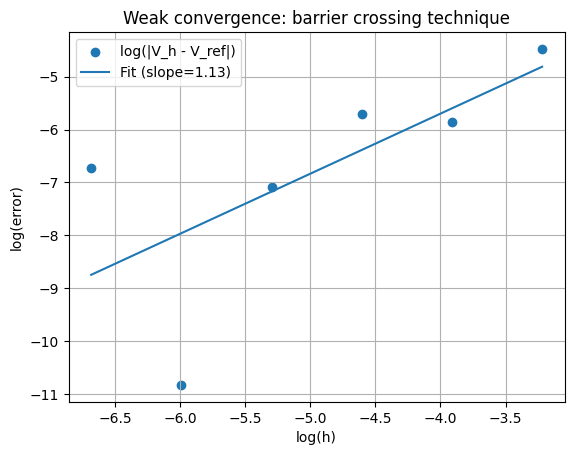

In [16]:
#check order of connvergence
values = np.array(values)
h_list = T / np.array(steps_list)
err = np.abs(values - ref)
log_h = np.log(h_list)
log_err = np.log(err)

slope, intercept = np.polyfit(log_h, log_err, 1)

# --- fitted line ---
log_h_line = np.linspace(min(log_h), max(log_h), 100)
log_err_line = slope * log_h_line + intercept

plt.figure()
plt.scatter(log_h,log_err, label='log(|V_h - V_ref|)')
plt.plot(log_h_line, log_err_line, label=f"Fit (slope={slope:.2f})")
#plt.plot(log_h, log_h, '--', label='O(h)')
plt.title('Weak convergence: barrier crossing technique')
plt.legend()
plt.xlabel("log(h)")
plt.ylabel("log(error)")
plt.grid(True)
plt.savefig("order.png")
plt.show()

### 4. Distribution of pathwise estimators
Histograms of pathwise Delta and Vega samples computed over paths with positive contribution to the estimator (i.e. $SW$ > 0 and $S_T > K$).

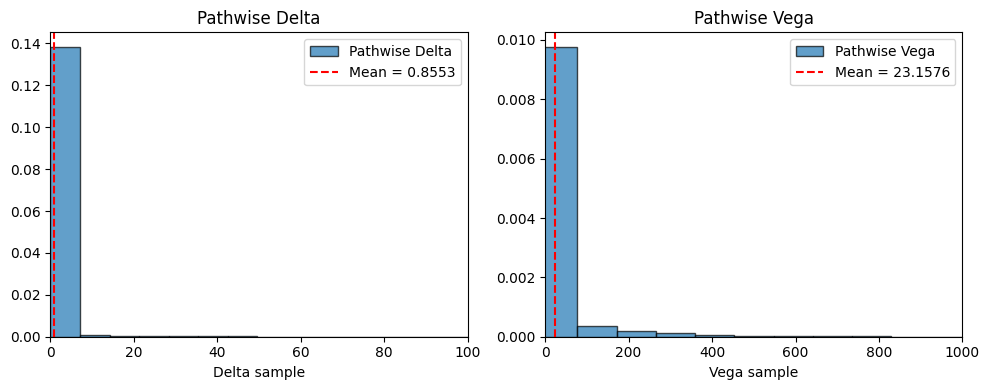

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(delta_samples, bins=50, density=True, alpha=0.7, edgecolor='k', label='Pathwise Delta')
axes[0].axvline(delta_hat, color='red', linestyle='--', label=f'Mean = {delta_hat:.4f}')
axes[0].set_xlabel('Delta sample')
axes[0].legend()
axes[0].set_title('Pathwise Delta')
axes[0].set_xlim(0, 100)   



axes[1].hist(vega_samples, bins=50, density=True, alpha=0.7, edgecolor='k', label='Pathwise Vega')
axes[1].axvline(vega_hat, color='red', linestyle='--', label=f'Mean = {vega_hat:.4f}')
axes[1].set_xlabel('Vega sample')
axes[1].legend()
axes[1].set_title('Pathwise Vega')
axes[1].set_xlim(0, 1000) 
plt.tight_layout()
plt.savefig("dist.png")
plt.show()

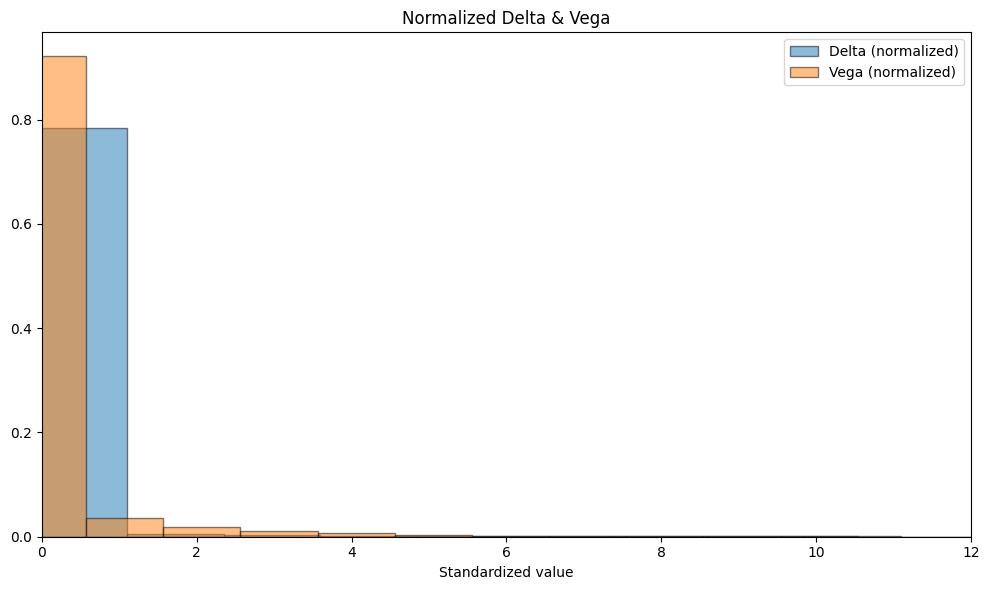

In [35]:
delta_norm = (delta_samples - delta_samples.mean()) / delta_samples.std()
vega_norm  = (vega_samples - vega_samples.mean()) / vega_samples.std()

plt.figure(figsize=(10, 6))

plt.hist(delta_norm, bins=50, density=True, alpha=0.5,
         edgecolor='k', label='Delta (normalized)')

plt.hist(vega_norm, bins=50, density=True, alpha=0.5,
         edgecolor='k', label='Vega (normalized)')

plt.xlabel('Standardized value')
plt.title('Normalized Delta & Vega')
plt.legend()
plt.xlim(0,12)
plt.tight_layout()
plt.savefig("dist1.png")
plt.show()

### 5. Additional Finite-difference Check
Validate pathwise Delta and Vega by comparing with finite-difference estimates: 
$$\Delta \approx (V(S_0+\varepsilon) - V(S_0-\varepsilon))/(2\varepsilon) $$
and similarly for Vega.

In [21]:
N_paths = 750000
N_steps = 400
def option_value_mc(S0, r, sigma, T, K, B, N_steps, N_paths, seed=None):
    S, W, h = simulate_gbm_paths(S0, r, sigma, T, N_steps, N_paths, seed=seed)
    one_minus_p = brownian_bridge(S, h, sigma, B)
    pay = pathwise_option_value(S, r, sigma, T, K, one_minus_p)
    return np.mean(pay)

eps_S0 = 1.0
eps_sigma = 0.01
V_center = option_value_mc(S0, r, sigma, T, K, B, N_steps, N_paths, seed=42)
V_plus_S0 = option_value_mc(S0 + eps_S0, r, sigma, T, K, B, N_steps, N_paths, seed=42)
V_minus_S0 = option_value_mc(S0 - eps_S0, r, sigma, T, K, B, N_steps, N_paths, seed=42)
delta_fd = (V_plus_S0 - V_minus_S0) / (2 * eps_S0)

V_plus_sigma = option_value_mc(S0, r, sigma + eps_sigma, T, K, B, N_steps, N_paths, seed=42)
V_minus_sigma = option_value_mc(S0, r, sigma - eps_sigma, T, K, B, N_steps, N_paths, seed=42)
vega_fd = (V_plus_sigma - V_minus_sigma) / (2 * eps_sigma)

In [26]:
print('Finite-difference vs pathwise:')
print(f'  Delta: FD = {delta_fd:.6f}, pathwise = {delta_hat:.6f}')
print(f'  Vega:  FD = {vega_fd:.6f}, pathwise = {vega_hat:.6f}')

Finite-difference vs pathwise:
  Delta: FD = 0.833111, pathwise = 0.855304
  Vega:  FD = 3.850538, pathwise = 23.157584
